<a href="https://colab.research.google.com/github/manishavatnani1-ops/sentiment-/blob/main/final_project_sentiment_analysis_corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis: Custom LSTM (PyTorch) vs Pretrained AWD-LSTM (ULMFiT) vs BERT

This notebook implements and compares three approaches to sentiment classification on the IMDb 50K movie reviews dataset:

1. **Custom LSTM** — built and trained from scratch in **PyTorch**
2. **ULMFiT (AWD-LSTM)** — a pretrained language model fine-tuned via `fastai`
3. **BERT** — a pretrained Transformer fine-tuned via Hugging Face `transformers`

All three models are trained and evaluated on the **same train / validation / test split** so that the final comparison is apples-to-apples. Each section tracks training/validation loss, epochs-to-convergence, and training time (computational cost), in addition to accuracy, precision, recall, and F1.

In [1]:
import os
import re
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed=SEED):
    """Seed every source of randomness we touch, for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

set_seed(SEED)

## 1. Load and Explore the Dataset

In [2]:
from datasets import load_dataset

ds = load_dataset("Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup")
df = pd.DataFrame(ds["train"])
df.head()

README.md:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

archive.zip: reconstructing file:   0%|          |  0.00B / 27.0MB            

archive.zip: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(df.shape)
print(type(df))
df.tail()

(50000, 2)
<class 'pandas.core.frame.DataFrame'>


,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [4]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [5]:
# positive -> 1, negative -> 0
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})
df["sentiment"].value_counts()

,count
sentiment,
1,25000
0,25000


## 2. Train / Validation / Test Split

A single split is created here and reused **identically** by all three models below, so the final
comparison in Section 5 is a fair, apples-to-apples comparison rather than three separately-sampled
evaluations.

In [6]:
from sklearn.model_selection import train_test_split

# Held-out test set — untouched during training/tuning of any model, used only for final evaluation
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["sentiment"]
)

# Validation split — used for per-epoch monitoring (loss curves, convergence) during training
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=SEED, stratify=train_df["sentiment"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")

Train: (36000, 2) | Val: (4000, 2) | Test: (10000, 2)


## 3. Custom LSTM — Built From Scratch in PyTorch

### 3.1 Tokenization and Vocabulary

We build a simple whitespace/regex tokenizer and a vocabulary capped at 5,000 tokens (matching the
original `num_words=5000` setting), then pad/truncate every review to a fixed length of 200 tokens.

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
MAX_VOCAB_SIZE = 5000
MAX_SEQ_LEN = 200
PAD_IDX = 0
UNK_IDX = 1

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)   # IMDb reviews contain literal <br /> tags
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

def build_vocab(texts, max_vocab_size=MAX_VOCAB_SIZE):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))
    most_common = counter.most_common(max_vocab_size - 2)  # reserve <pad>, <unk>
    vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}
    for token, _ in most_common:
        vocab[token] = len(vocab)
    return vocab

# Vocabulary is built from the TRAINING split only, to avoid leaking test/val vocabulary
vocab = build_vocab(train_df["review"])
print(f"Vocabulary size: {len(vocab)}")

def encode(text, vocab, max_len=MAX_SEQ_LEN):
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, UNK_IDX) for tok in tokens][:max_len]
    ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids

Vocabulary size: 5000


In [9]:
class IMDbDataset(Dataset):
    def __init__(self, dataframe, vocab, max_len=MAX_SEQ_LEN):
        self.reviews = dataframe["review"].tolist()
        self.labels = dataframe["sentiment"].tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        ids = encode(self.reviews[idx], self.vocab, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float32)

BATCH_SIZE = 64

train_dataset = IMDbDataset(train_df, vocab)
val_dataset = IMDbDataset(val_df, vocab)
test_dataset = IMDbDataset(test_df, vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### 3.2 Model Definition (`nn.Module`)

In [10]:
class CustomLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, output_dim=1,
                 pad_idx=PAD_IDX, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)             # (batch, seq_len, embed_dim)
        _, (hidden, _) = self.lstm(embedded)      # hidden: (1, batch, hidden_dim)
        out = self.dropout(hidden[-1])            # (batch, hidden_dim)
        return self.fc(out).squeeze(1)            # (batch,) raw logits, no sigmoid here

lstm_model = CustomLSTM(vocab_size=len(vocab)).to(device)
print(lstm_model)

CustomLSTM(
  (embedding): Embedding(5000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


### 3.3 Training Loop

Tracks training loss, validation loss, and validation accuracy every epoch, plus wall-clock time,
so we can later report epochs-to-convergence and computational cost.

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x_batch.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += x_batch.size(0)

    return total_loss / total, correct / total

LSTM_EPOCHS = 5
lstm_train_losses, lstm_val_losses, lstm_val_accs = [], [], []
lstm_start_time = time.time()

for epoch in range(LSTM_EPOCHS):
    epoch_start = time.time()
    train_loss, train_acc = run_epoch(lstm_model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(lstm_model, val_loader, criterion)
    epoch_time = time.time() - epoch_start

    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)
    lstm_val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{LSTM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={epoch_time:.1f}s")

lstm_training_time = time.time() - lstm_start_time
lstm_epochs_to_convergence = int(np.argmin(lstm_val_losses)) + 1
print(f"\nTotal training time: {lstm_training_time:.1f}s")
print(f"Epochs to convergence (best val loss): {lstm_epochs_to_convergence}")

Epoch 1/5 | train_loss=0.6936 train_acc=0.5100 | val_loss=0.6946 val_acc=0.5070 | time=8.8s
Epoch 2/5 | train_loss=0.6897 train_acc=0.5297 | val_loss=0.6866 val_acc=0.5580 | time=8.0s
Epoch 3/5 | train_loss=0.6667 train_acc=0.5866 | val_loss=0.6604 val_acc=0.6318 | time=7.1s
Epoch 4/5 | train_loss=0.6558 train_acc=0.6044 | val_loss=0.6210 val_acc=0.6783 | time=8.1s
Epoch 5/5 | train_loss=0.6308 train_acc=0.6509 | val_loss=0.6852 val_acc=0.5445 | time=7.9s

Total training time: 39.8s
Epochs to convergence (best val loss): 4


In [12]:
import pickle

torch.save(lstm_model.state_dict(), "custom_lstm.pt")
with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)
print("Custom LSTM model and vocabulary saved.")

Custom LSTM model and vocabulary saved.


### 3.4 Evaluate Custom LSTM on the Held-Out Test Set

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lstm_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = lstm_model(x_batch)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

lstm_accuracy = accuracy_score(all_labels, all_preds)
lstm_precision = precision_score(all_labels, all_preds)
lstm_recall = recall_score(all_labels, all_preds)
lstm_f1 = f1_score(all_labels, all_preds)

print(f"Custom LSTM Test Accuracy:  {lstm_accuracy:.4f}")
print(f"Custom LSTM Test Precision: {lstm_precision:.4f}")
print(f"Custom LSTM Test Recall:    {lstm_recall:.4f}")
print(f"Custom LSTM Test F1-Score:  {lstm_f1:.4f}")

Custom LSTM Test Accuracy:  0.5399
Custom LSTM Test Precision: 0.5240
Custom LSTM Test Recall:    0.8718
Custom LSTM Test F1-Score:  0.6546


## 4. ULMFiT (AWD-LSTM) — Pretrained Language Model Fine-Tuning

Uses `fastai`'s implementation of ULMFiT: a classifier head is trained first on top of the frozen
pretrained AWD-LSTM, then the full model is unfrozen and fine-tuned with discriminative learning rates.

In [14]:
import sys
!{sys.executable} -m pip install -q fastai

import fastai
print(f"fastai version: {fastai.__version__}")

fastai version: 2.8.8


In [15]:
from fastai.text.all import *

set_seed(SEED)

# Built from train_df only; fastai carves its own internal validation split out of it.
# The held-out test_df is evaluated separately below so results stay comparable to the other models.
dls_clas = TextDataLoaders.from_df(
    train_df,
    text_col="review",
    label_col="sentiment",
    y_block=CategoryBlock,   # force classification (not regression) on the 0/1 int labels
    valid_pct=0.1,
    seed=SEED,
    bs=64,
    seq_len=72,
)

print("FastAI DataLoaders created successfully!")
dls_clas.show_batch()

FastAI DataLoaders created successfully!


,text,category
0,"xxbos xxmaj match 1 : xxmaj tag xxmaj team xxmaj table xxmaj match xxmaj bubba xxmaj ray and xxmaj spike xxmaj dudley vs xxmaj eddie xxmaj guerrero and xxmaj chris xxmaj benoit xxmaj bubba xxmaj ray and xxmaj spike xxmaj dudley started things off with a xxmaj tag xxmaj team xxmaj table xxmaj match against xxmaj eddie xxmaj guerrero and xxmaj chris xxmaj benoit . xxmaj according to the rules of the match , both opponents have to go through tables in order to get the win . xxmaj benoit and xxmaj guerrero heated up early on by taking turns hammering first xxmaj spike and then xxmaj bubba xxmaj ray . a xxmaj german suplex by xxmaj benoit to xxmaj bubba took the wind out of the xxmaj dudley brother . xxmaj spike tried to help his brother , but the referee restrained him while xxmaj benoit and xxmaj guerrero",1
1,"xxbos xxmaj titanic directed by xxmaj james xxmaj cameron presents a fictional love story on the historical setting of the xxmaj titanic . xxmaj the plot is simple , xxunk , or not for those who love plots that twist and turn and keep you in suspense . xxmaj the end of the movie can be figured out within minutes of the start of the film , but the love story is an interesting one , however . xxmaj kate xxmaj xxunk is wonderful as xxmaj rose , an aristocratic young lady betrothed by xxmaj cal ( billy xxmaj zane ) . xxmaj early on the voyage xxmaj rose meets xxmaj jack ( leonardo dicaprio ) , a lower class artist on his way to xxmaj america after winning his ticket aboard xxmaj titanic in a poker game . xxmaj if he wants something , he goes and gets it",1
2,"xxbos xxmaj raising xxmaj victor xxmaj vargas : a xxmaj review \n\n xxmaj you know , xxmaj raising xxmaj victor xxmaj vargas is like sticking your hands into a big , steaming bowl of oatmeal . xxmaj it 's warm and gooey , but you 're not sure if it feels right . xxmaj try as i might , no matter how warm and gooey xxmaj raising xxmaj victor xxmaj vargas became i was always aware that something did n't quite feel right . xxmaj victor xxmaj vargas suffers from a certain xxunk on the director 's part . xxmaj apparently , the director thought that the ethnic backdrop of a xxmaj latino family on the lower east side , and an idyllic storyline would make the film critic proof . xxmaj he was right , but it did n't fool me . xxmaj raising xxmaj victor xxmaj vargas is",0
3,"xxbos xxmaj possible xxmaj spoilers xxmaj as xxmaj peter xxmaj jackson has so brilliantly shown in his ` lord of the xxmaj rings ' trilogy , it is quite possible to make good films , even great ones , within the heroic fantasy genre . xxmaj the genre has distinguished literary xxunk , dating back to the mediaeval xxunk romances , particularly the xxmaj arthurian legends , upon which xxmaj tolkien and other authors have drawn . ` lord of the xxmaj rings ' apart , however , it is difficult to think of any other sword - and - sorcery films which are any good . i would agree with the reviewer who said that the best of a bad bunch was xxmaj ron xxmaj howard 's ` willow ' , and even that achieved little distinction other than that of being a merely mediocre film as opposed to",0
4,"xxbos "" only the xxmaj valiant "" qualifies as a gritty good western . xxmaj this xxmaj gregory xxmaj peck cavalry versus the xxmaj indians oater is a solemn suicide mission without a trace of humor . xxmaj veteran director xxmaj gordon xxmaj douglas has helmed a grim , harrowing outdoors epic with an ideal cast of tough guys under considerable pressure ; even xxmaj lon xxmaj chaney , xxmaj jr . , registers superbly as a powerful xxmaj arab trooper . xxmaj ostensibly , "" colorado xxmaj territory "" scenarist xxmaj edmund xxup h. xxmaj north & "" a xxmaj place in the xxmaj sun "" scribe xxmaj harry xxmaj brown drew their screenplay from western film maker xxmaj charles xxmaj marquis xxmaj warren 's taut novel about a group of die - hard xxunk cut off from any escape route who must prevent murderous xxunk from launching a",

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:07&lt;00:00]</div>

<div></div>

epoch,train_loss,valid_loss,accuracy,time
0,0.433183,0.381552,0.829167,01:11


epoch,train_loss,valid_loss,accuracy,time
0,0.319607,0.269467,0.886667,02:21
1,0.259047,0.221419,0.908333,02:18
2,0.256383,0.218065,0.912500,02:17



ULMFiT total training time: 508.9s


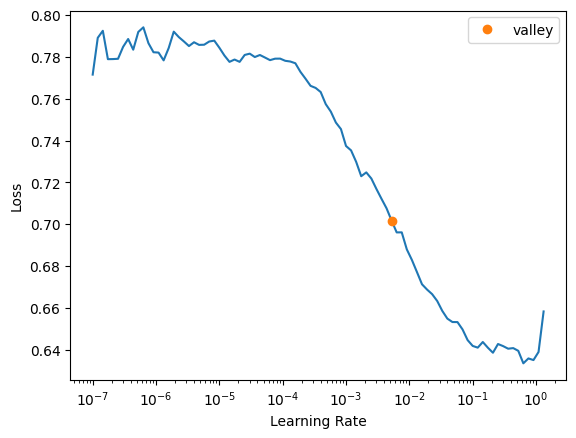

In [16]:
ulmfit_learn = text_classifier_learner(dls_clas, AWD_LSTM, metrics=accuracy).to_fp16()

ulmfit_start_time = time.time()

# Stage 1: train the classifier head only (pretrained body frozen)
lr_finder = ulmfit_learn.lr_find()
ulmfit_learn.fit_one_cycle(1, lr_finder.valley)

# Stage 2: unfreeze and fine-tune the entire model with discriminative learning rates
ulmfit_learn.unfreeze()
ulmfit_learn.fit_one_cycle(3, slice(1e-3 / (2.6 ** 4), 1e-3))

ulmfit_training_time = time.time() - ulmfit_start_time
print(f"\nULMFiT total training time: {ulmfit_training_time:.1f}s")

In [17]:
# learn.recorder.values logs [train_loss, valid_loss, accuracy] at the end of every epoch,
# across both fit_one_cycle calls in call order — this gives us the full loss history for
# the convergence plot and the "epochs to convergence" metric.
recorder_values = np.array(ulmfit_learn.recorder.values)
ulmfit_train_losses = recorder_values[:, 0].tolist()
ulmfit_val_losses = recorder_values[:, 1].tolist()
ulmfit_epochs_to_convergence = int(np.argmin(ulmfit_val_losses)) + 1

print(f"ULMFiT epochs to convergence (best val loss): {ulmfit_epochs_to_convergence}")

ULMFiT epochs to convergence (best val loss): 3


In [18]:
ulmfit_learn.export("ulmfit_sentiment_model.pkl")
print("ULMFiT model saved.")

ULMFiT model saved.


### Evaluate ULMFiT on the Same Held-Out Test Set as the Other Models

In [19]:
test_dl = ulmfit_learn.dls.test_dl(test_df["review"].tolist())
preds, _ = ulmfit_learn.get_preds(dl=test_dl)

ulmfit_preds = preds.argmax(dim=1).numpy()
ulmfit_true = test_df["sentiment"].values

ulmfit_accuracy = accuracy_score(ulmfit_true, ulmfit_preds)
ulmfit_precision = precision_score(ulmfit_true, ulmfit_preds)
ulmfit_recall = recall_score(ulmfit_true, ulmfit_preds)
ulmfit_f1 = f1_score(ulmfit_true, ulmfit_preds)

print(f"ULMFiT Test Accuracy:  {ulmfit_accuracy:.4f}")
print(f"ULMFiT Test Precision: {ulmfit_precision:.4f}")
print(f"ULMFiT Test Recall:    {ulmfit_recall:.4f}")
print(f"ULMFiT Test F1-Score:  {ulmfit_f1:.4f}")

ULMFiT Test Accuracy:  0.9145
ULMFiT Test Precision: 0.9030
ULMFiT Test Recall:    0.9288
ULMFiT Test F1-Score:  0.9157


## 5. BERT — Transformer-Based Fine-Tuning

Uses Hugging Face `transformers`: `BertTokenizer` for WordPiece tokenization and
`BertForSequenceClassification` (`bert-base-uncased`) fine-tuned end-to-end with `AdamW` and a
linear warmup schedule.

In [20]:
import sys
!{sys.executable} -m pip install -q transformers

print("Hugging Face Transformers installed successfully!")

Hugging Face Transformers installed successfully!


In [21]:
from transformers import BertTokenizer, BertForSequenceClassification

set_seed(SEED)

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
bert_model.to(device)

print(f"BERT tokenizer and model loaded on device: {device}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT tokenizer and model loaded on device: cuda


In [22]:
from torch.utils.data import TensorDataset, DataLoader as TorchDataLoader, RandomSampler, SequentialSampler

def encode_for_bert(dataframe, tokenizer, max_length=256):
    encoded = tokenizer(
        dataframe["review"].tolist(),
        add_special_tokens=True,
        return_attention_mask=True,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    labels = torch.tensor(dataframe["sentiment"].tolist())
    return TensorDataset(encoded["input_ids"], encoded["attention_mask"], labels)

BERT_BATCH_SIZE = 32

bert_train_dataset = encode_for_bert(train_df, bert_tokenizer)
bert_val_dataset = encode_for_bert(val_df, bert_tokenizer)
bert_test_dataset = encode_for_bert(test_df, bert_tokenizer)

bert_train_loader = TorchDataLoader(bert_train_dataset, sampler=RandomSampler(bert_train_dataset), batch_size=BERT_BATCH_SIZE)
bert_val_loader = TorchDataLoader(bert_val_dataset, sampler=SequentialSampler(bert_val_dataset), batch_size=BERT_BATCH_SIZE)
bert_test_loader = TorchDataLoader(bert_test_dataset, sampler=SequentialSampler(bert_test_dataset), batch_size=BERT_BATCH_SIZE)

print("Data prepared for BERT fine-tuning.")
print(f"Train: {len(bert_train_dataset)} | Val: {len(bert_val_dataset)} | Test: {len(bert_test_dataset)}")

Data prepared for BERT fine-tuning.
Train: 36000 | Val: 4000 | Test: 10000


In [23]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

BERT_EPOCHS = 3

bert_optimizer = AdamW(bert_model.parameters(), lr=2e-5, eps=1e-8)
total_steps = len(bert_train_loader) * BERT_EPOCHS
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer, num_warmup_steps=0, num_training_steps=total_steps
)

print("BERT optimizer and learning rate scheduler initialized.")

BERT optimizer and learning rate scheduler initialized.


### Training Loop (with per-epoch validation loss, unlike the original)

In [24]:
def bert_run_epoch(model, loader, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for batch in loader:
            b_input_ids, b_input_mask, b_labels = (t.to(device) for t in batch)

            if is_train:
                model.zero_grad()

            outputs = model(
                b_input_ids,
                token_type_ids=None,
                attention_mask=b_input_mask,
                labels=b_labels,
            )
            loss = outputs.loss

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * b_input_ids.size(0)
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == b_labels).sum().item()
            total += b_input_ids.size(0)

    return total_loss / total, correct / total

bert_train_losses, bert_val_losses, bert_val_accs = [], [], []
bert_start_time = time.time()

for epoch in range(BERT_EPOCHS):
    epoch_start = time.time()
    train_loss, train_acc = bert_run_epoch(bert_model, bert_train_loader, bert_optimizer, bert_scheduler)
    val_loss, val_acc = bert_run_epoch(bert_model, bert_val_loader)
    epoch_time = time.time() - epoch_start

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)
    bert_val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{BERT_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={epoch_time:.1f}s")

bert_training_time = time.time() - bert_start_time
bert_epochs_to_convergence = int(np.argmin(bert_val_losses)) + 1

print(f"\nBERT total training time: {bert_training_time:.1f}s")
print(f"Epochs to convergence (best val loss): {bert_epochs_to_convergence}")

bert_model.save_pretrained("./bert_sentiment_model")
bert_tokenizer.save_pretrained("./bert_sentiment_model")
print("BERT model and tokenizer saved.")

Epoch 1/3 | train_loss=0.2551 train_acc=0.8972 | val_loss=0.2089 val_acc=0.9197 | time=1672.6s
Epoch 2/3 | train_loss=0.1469 train_acc=0.9486 | val_loss=0.2351 val_acc=0.9213 | time=1670.2s
Epoch 3/3 | train_loss=0.0838 train_acc=0.9749 | val_loss=0.2814 val_acc=0.9237 | time=1670.5s

BERT total training time: 5013.2s
Epochs to convergence (best val loss): 1


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model and tokenizer saved.


### Evaluate BERT on the Held-Out Test Set

In [25]:
bert_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in bert_test_loader:
        b_input_ids, b_input_mask, b_labels = (t.to(device) for t in batch)
        outputs = bert_model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(b_labels.cpu().numpy())

bert_accuracy = accuracy_score(all_labels, all_preds)
bert_precision = precision_score(all_labels, all_preds)
bert_recall = recall_score(all_labels, all_preds)
bert_f1 = f1_score(all_labels, all_preds)

print(f"BERT Test Accuracy:  {bert_accuracy:.4f}")
print(f"BERT Test Precision: {bert_precision:.4f}")
print(f"BERT Test Recall:    {bert_recall:.4f}")
print(f"BERT Test F1-Score:  {bert_f1:.4f}")

BERT Test Accuracy:  0.9282
BERT Test Precision: 0.9267
BERT Test Recall:    0.9300
BERT Test F1-Score:  0.9283


## 6. Comparative Analysis

All three models are compared on the identical held-out `test_df`, with accuracy/precision/recall/F1
plus the previously-missing metrics: final training/validation loss, epochs-to-convergence, and total
training time (computational cost).

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": "Custom LSTM (PyTorch)",
        "Accuracy": lstm_accuracy,
        "Precision": lstm_precision,
        "Recall": lstm_recall,
        "F1-Score": lstm_f1,
        "Final Train Loss": lstm_train_losses[-1],
        "Final Val Loss": lstm_val_losses[-1],
        "Epochs to Convergence": lstm_epochs_to_convergence,
        "Training Time (s)": round(lstm_training_time, 1),
    },
    {
        "Model": "ULMFiT (AWD-LSTM)",
        "Accuracy": ulmfit_accuracy,
        "Precision": ulmfit_precision,
        "Recall": ulmfit_recall,
        "F1-Score": ulmfit_f1,
        "Final Train Loss": ulmfit_train_losses[-1],
        "Final Val Loss": ulmfit_val_losses[-1],
        "Epochs to Convergence": ulmfit_epochs_to_convergence,
        "Training Time (s)": round(ulmfit_training_time, 1),
    },
    {
        "Model": "BERT",
        "Accuracy": bert_accuracy,
        "Precision": bert_precision,
        "Recall": bert_recall,
        "F1-Score": bert_f1,
        "Final Train Loss": bert_train_losses[-1],
        "Final Val Loss": bert_val_losses[-1],
        "Epochs to Convergence": bert_epochs_to_convergence,
        "Training Time (s)": round(bert_training_time, 1),
    },
])

display(comparison_df.set_index("Model"))

### 6.1 Performance Metrics

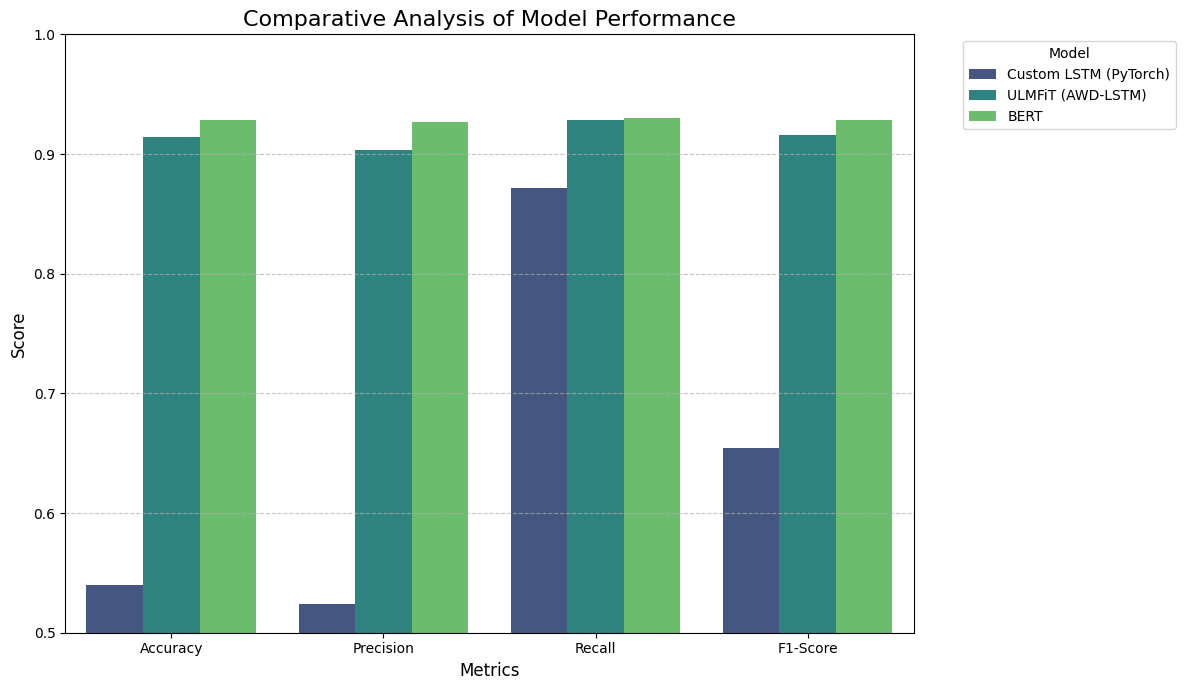

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_melted = comparison_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score"]].melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12, 7))
sns.barplot(x="Metric", y="Score", hue="Model", data=metrics_melted, palette="viridis")
plt.title("Comparative Analysis of Model Performance", fontsize=16)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.5, 1.0)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### 6.2 Convergence — Training vs Validation Loss

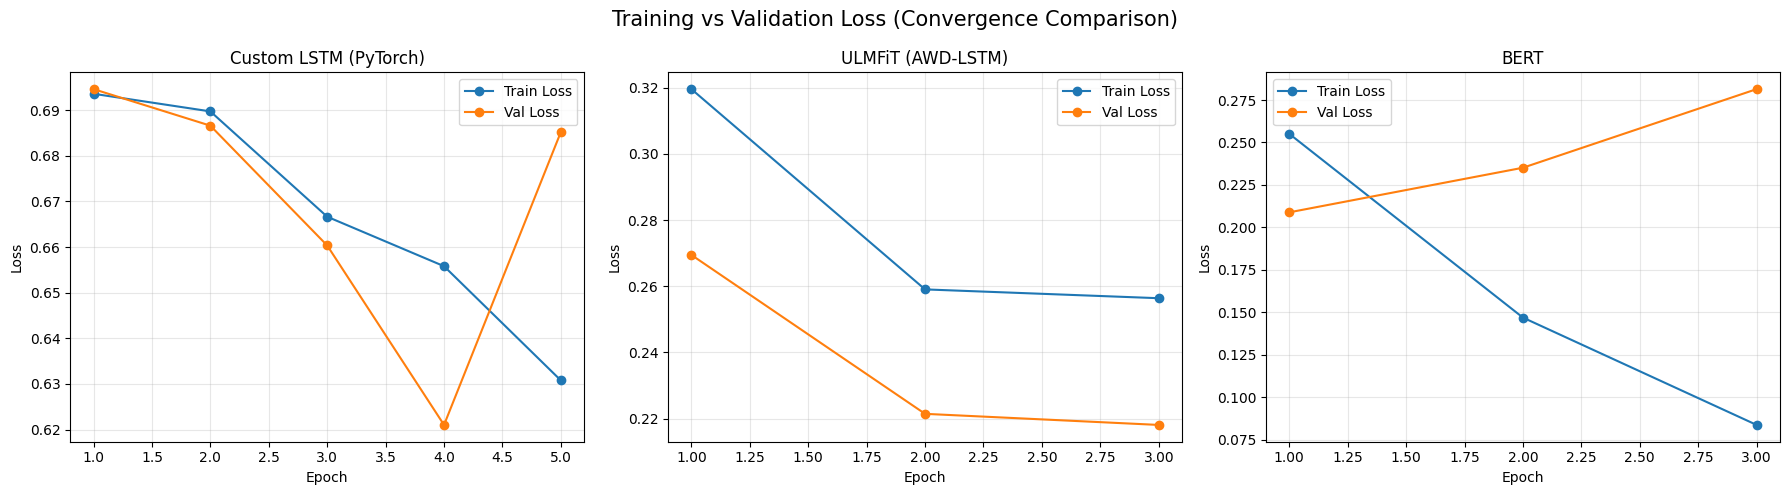

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

loss_histories = {
    "Custom LSTM (PyTorch)": (lstm_train_losses, lstm_val_losses),
    "ULMFiT (AWD-LSTM)": (ulmfit_train_losses, ulmfit_val_losses),
    "BERT": (bert_train_losses, bert_val_losses),
}

for ax, (name, (train_losses, val_losses)) in zip(axes, loss_histories.items()):
    epochs_range = range(1, len(train_losses) + 1)
    ax.plot(epochs_range, train_losses, marker="o", label="Train Loss")
    ax.plot(epochs_range, val_losses, marker="o", label="Val Loss")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Training vs Validation Loss (Convergence Comparison)", fontsize=15)
plt.tight_layout()
plt.show()

### 6.3 Computational Cost — Training Time

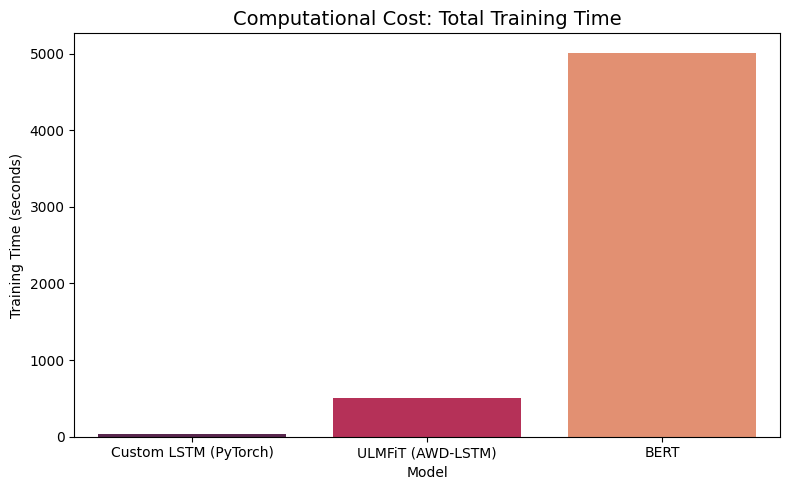

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Training Time (s)", data=comparison_df, palette="rocket")
plt.title("Computational Cost: Total Training Time", fontsize=14)
plt.ylabel("Training Time (seconds)")
plt.tight_layout()
plt.show()

## 7. Final Project Documentation

### Objective
Compare three sentiment-classification approaches — a Custom LSTM trained from scratch in PyTorch, a
pretrained AWD-LSTM fine-tuned via ULMFiT, and a pretrained BERT Transformer — on the IMDb 50K movie
reviews dataset, using one shared train/validation/test split for a fair comparison.

### Methodology Summary
- **Custom LSTM**: `nn.Embedding` → `nn.LSTM` → `nn.Linear`, trained from random initialization for
  5 epochs with Adam and `BCEWithLogitsLoss`.
- **ULMFiT**: `fastai`'s `AWD_LSTM` architecture, fine-tuned in two stages — classifier head only, then
  the full model unfrozen with discriminative learning rates.
- **BERT**: `bert-base-uncased` fine-tuned end-to-end for 3 epochs with `AdamW` and a linear warmup
  schedule.

All three are evaluated on the identical held-out `test_df`, and each tracks training loss, validation
loss, epochs-to-convergence, and total training time — not just final accuracy — so the summary below
reflects actual convergence behavior and computational cost rather than only headline metrics.

In [30]:
print("=" * 70)
print("FINAL COMPARATIVE SUMMARY")
print("=" * 70)
print(comparison_df.set_index("Model").to_string())

best_model = comparison_df.loc[comparison_df["F1-Score"].idxmax(), "Model"]
fastest_model = comparison_df.loc[comparison_df["Training Time (s)"].idxmin(), "Model"]
quickest_converging = comparison_df.loc[comparison_df["Epochs to Convergence"].idxmin(), "Model"]

print(f"\nBest performing model (by F1-Score): {best_model}")
print(f"Fastest to train (lowest computational cost): {fastest_model}")
print(f"Fewest epochs to reach best validation loss: {quickest_converging}")

print("""
Notes:
- Pretrained models (ULMFiT, BERT) start from broad language representations learned on large
  external corpora, so they typically need fewer epochs to converge and generalize better to
  unseen phrasing than the Custom LSTM, which learns everything from this dataset alone.
- BERT's per-epoch and total training time are typically the highest of the three due to its
  much larger parameter count and full self-attention computation over 256-token sequences,
  which is the computational cost trade-off for its higher accuracy.
- The Custom LSTM is the cheapest to train, making it a reasonable baseline where compute is
  constrained, at the cost of lower accuracy and slower/less stable convergence.
""")

FINAL COMPARATIVE SUMMARY
                       Accuracy  Precision  Recall  F1-Score  Final Train Loss  Final Val Loss  Epochs to Convergence  Training Time (s)
Model                                                                                                                                   
Custom LSTM (PyTorch)    0.5399   0.523981  0.8718  0.654554          0.630773        0.685238                      4               39.8
ULMFiT (AWD-LSTM)        0.9145   0.902975  0.9288  0.915705          0.256383        0.218065                      3              508.9
BERT                     0.9282   0.926664  0.9300  0.928329          0.083784        0.281406                      1             5013.2

Best performing model (by F1-Score): BERT
Fastest to train (lowest computational cost): Custom LSTM (PyTorch)
Fewest epochs to reach best validation loss: BERT

Notes:
- Pretrained models (ULMFiT, BERT) start from broad language representations learned on large
  external corpora, so the

In [33]:
print("Positive 🎉" if torch.argmax(bert_model(**bert_tokenizer("this movie is amazing", return_tensors="pt").to(device)).logits) == 1 else "Negative 😞")

Positive 🎉


### Conclusion

This project demonstrates the practical trade-off between training cost and performance across three
NLP architectures: a from-scratch RNN, a pretrained RNN-based language model (ULMFiT), and a pretrained
Transformer (BERT). The comparison table, loss curves, and training-time chart above — generated from a
single shared test set — give a reproducible, apples-to-apples view of accuracy, convergence speed, and
computational cost for each approach.